In [1]:
import pandas as pd

df = pd.read_csv("gold_analysis_sample.csv")

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("gold_analysis_sample.csv")

df.head()


,playerid,platform,completion_ratio,normalized_score,engagement_score
0,2329278,XBOX,0.134146,0.055862,0.102833
1,76561198977284380,STEAM,0.397849,NaN,0.397849
2,1800385,PS,0.976744,0.346939,0.724822
3,791967,XBOX,0.157895,0.041811,0.111461
4,330498,PS,0.680000,0.320296,0.536118


In [3]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns)

print("\nMissing values:")
print(df.isnull().sum())

print("\nPlatform counts:")
print(df["platform"].value_counts())

df.describe(include="all")

Shape: (5000, 5)

Columns:
Index(['playerid', 'platform', 'completion_ratio', 'normalized_score',
       'engagement_score'],
      dtype='object')

Missing values:
playerid              0
platform              0
completion_ratio      0
normalized_score    690
engagement_score      0
dtype: int64

Platform counts:
platform
XBOX     2168
PS       2142
STEAM     690
Name: count, dtype: int64


,playerid,platform,completion_ratio,normalized_score,engagement_score
count,5.000000e+03,5000,5000.000000,4310.000000,5000.000000
unique,NaN,3,NaN,NaN,NaN
top,NaN,XBOX,NaN,NaN,NaN
freq,NaN,2168,NaN,NaN,NaN
mean,1.056545e+16,NaN,0.309127,0.186540,0.264954
std,2.640860e+16,NaN,0.268417,0.146648,0.191248
min,1.786000e+03,NaN,0.001506,0.022239,0.001506
25%,7.492930e+05,NaN,0.080000,0.039535,0.120362
50%,1.311325e+06,NaN,0.229041,0.107918,0.219885
75%,3.311109e+06,NaN,0.483871,0.323959,0.384553


In [4]:
df["engagement_score"] = np.where(
    df["platform"] == "STEAM",
    df["completion_ratio"],
    0.6 * df["completion_ratio"] + 0.4 * df["normalized_score"]
)

df.head()

,playerid,platform,completion_ratio,normalized_score,engagement_score
0,2329278,XBOX,0.134146,0.055862,0.102833
1,76561198977284380,STEAM,0.397849,NaN,0.397849
2,1800385,PS,0.976744,0.346939,0.724822
3,791967,XBOX,0.157895,0.041811,0.111461
4,330498,PS,0.680000,0.320296,0.536118


In [5]:
summary = df.groupby("platform")[["completion_ratio", "normalized_score", "engagement_score"]].mean()

print(summary)

          completion_ratio  normalized_score  engagement_score
platform                                                      
PS                0.340578          0.332028          0.337158
STEAM             0.274619               NaN          0.274619
XBOX              0.289036          0.042797          0.190541


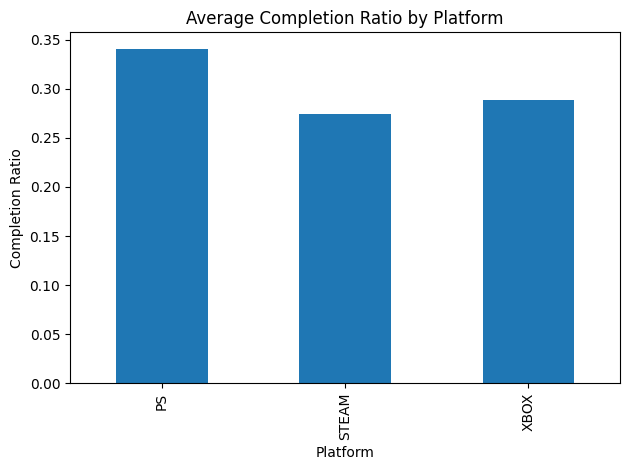

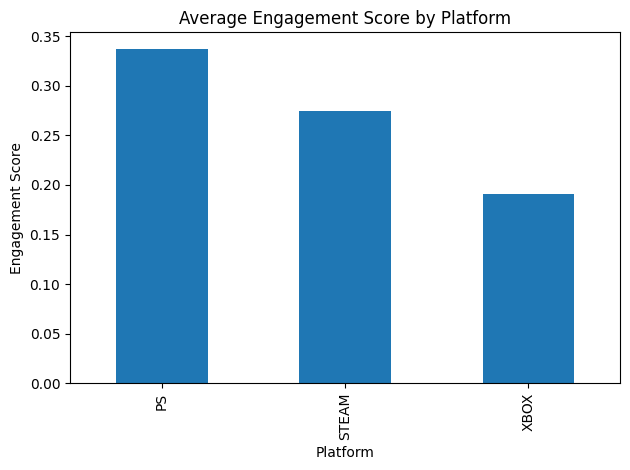

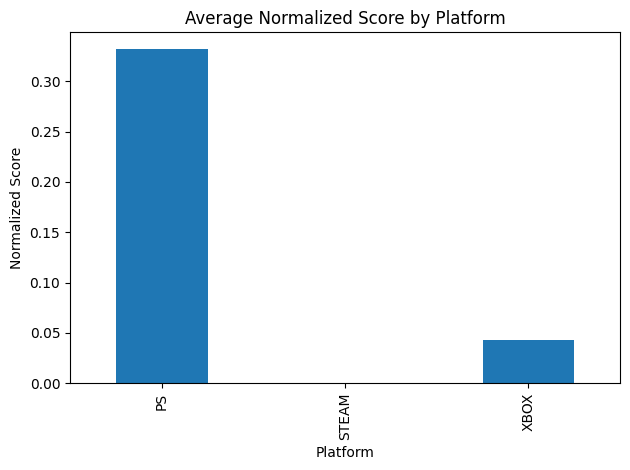

In [6]:
# Grafik 1: Ortalama completion ratio
summary["completion_ratio"].plot(kind="bar")
plt.title("Average Completion Ratio by Platform")
plt.ylabel("Completion Ratio")
plt.xlabel("Platform")
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/Colab Notebooks/avg_completion_by_platform.png")
plt.show()

# Grafik 2: Ortalama engagement score
summary["engagement_score"].plot(kind="bar")
plt.title("Average Engagement Score by Platform")
plt.ylabel("Engagement Score")
plt.xlabel("Platform")
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/Colab Notebooks/avg_engagement_by_platform.png")
plt.show()

# Grafik 3: Ortalama normalized score
summary["normalized_score"].plot(kind="bar")
plt.title("Average Normalized Score by Platform")
plt.ylabel("Normalized Score")
plt.xlabel("Platform")
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/Colab Notebooks/avg_normalized_score_by_platform.png")
plt.show()

In [7]:
df.sample(5000).to_csv("gold_analysis_sample.csv", index=False)

In [8]:
print("Dataset shape:", df.shape)
print("\nColumns:")
print(df.columns)

df.describe()

Dataset shape: (5000, 5)

Columns:
Index(['playerid', 'platform', 'completion_ratio', 'normalized_score',
       'engagement_score'],
      dtype='object')


,playerid,completion_ratio,normalized_score,engagement_score
count,5.000000e+03,5000.000000,4310.000000,5000.000000
mean,1.056545e+16,0.309127,0.186540,0.264954
std,2.640860e+16,0.268417,0.146648,0.191248
min,1.786000e+03,0.001506,0.022239,0.001506
25%,7.492930e+05,0.080000,0.039535,0.120362
50%,1.311325e+06,0.229041,0.107918,0.219885
75%,3.311109e+06,0.483871,0.323959,0.384553
max,7.656120e+16,1.000000,0.529138,1.000000


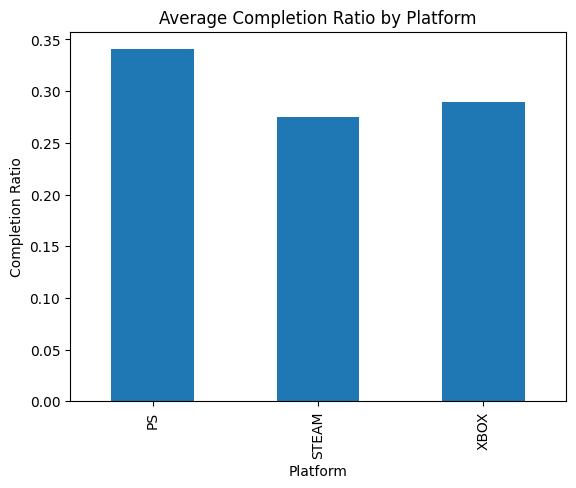

In [9]:
df.groupby("platform")["completion_ratio"].mean().plot(kind="bar")

plt.title("Average Completion Ratio by Platform")
plt.ylabel("Completion Ratio")
plt.xlabel("Platform")

plt.show()

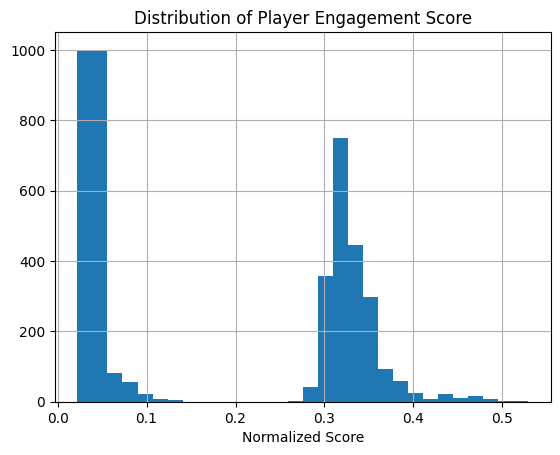

In [10]:
df["normalized_score"].hist(bins=30)

plt.title("Distribution of Player Engagement Score")
plt.xlabel("Normalized Score")

plt.show()

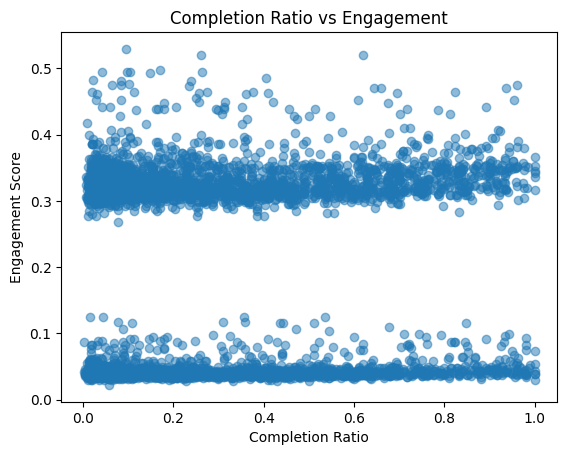

In [11]:
plt.scatter(df["completion_ratio"], df["normalized_score"], alpha=0.5)

plt.xlabel("Completion Ratio")
plt.ylabel("Engagement Score")
plt.title("Completion Ratio vs Engagement")

plt.show()

In [13]:
from sklearn.linear_model import LinearRegression

ml_df = df[df["normalized_score"].notna()].copy()

X = ml_df[["completion_ratio"]]
y = ml_df["normalized_score"]

model = LinearRegression()
model.fit(X, y)

print("Coefficient:", model.coef_[0])
print("Intercept:", model.intercept_)

Coefficient: 0.06230124969341299
Intercept: 0.16693682164393123
